In [43]:
import sklearn
from sklearn.datasets import make_circles

In [44]:
n_samples = 1000
x,y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

In [45]:
len(x),len(y)

(1000, 1000)

In [46]:
import pandas as pd
circles = pd.DataFrame({'x1':x[:,0],
                        'x2':x[:,1],
                        'label':y})
circles

,x1,x2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


In [47]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

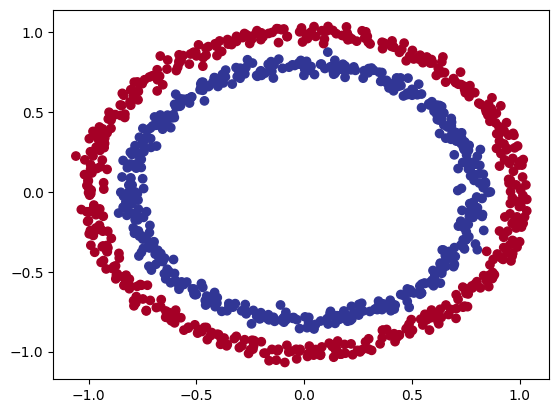

In [48]:
import matplotlib.pyplot as plt 
plt.scatter(x=x[:,0],y=x[:,1],c=y,cmap=plt.cm.RdYlBu)


In [49]:
x.shape,y.shape

((1000, 2), (1000,))

In [50]:
import torch 
x = torch.from_numpy(x).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

In [51]:
type(x)

torch.Tensor

In [52]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)

In [53]:
len(x_train),len(x_test)

(800, 200)

## building the model

In [54]:
from torch import nn

device ="mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [55]:
x_train.shape

torch.Size([800, 2])

In [56]:
class circleModelv0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,out_features=5)
        self.layer_2 = nn.Linear(in_features=5,out_features=1)

    def forward(self,x):
        return self.layer_2(self.layer_1(x))

model_0 = circleModelv0().to(device)
model_0

circleModelv0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

for smaller models we can also use sequential()

In [57]:
class circleModelv1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,out_features=10)
        self.layer_2 = nn.Linear(in_features=10,out_features=10)
        self.layer_3 = nn.Linear(in_features=10,out_features=1)


    def forward(self,x):
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = circleModelv1().to(device)
model_1

circleModelv1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [58]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188]], device='mps:0')),
             ('layer_1.bias',
              tensor([0.6146, 0.1323, 0.5224, 0.0958, 0.3410], device='mps:0')),
             ('layer_2.weight',
              tensor([[-0.0631,  0.3448,  0.0661, -0.2088,  0.1140]], device='mps:0')),
             ('layer_2.bias', tensor([-0.2060], device='mps:0'))])

In [59]:
with torch.inference_mode(): 
    untrained_pred = model_0(x_test.to(device))
torch.round(untrained_pred)

tensor([[-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-

which loss function to use ?

for regsression model we use MAE or MSE 

for classification model we use binary cross entropy or categorical cross entropy 

## BCELoss():
it requires the input to already have gone through a sigmoid dunction 

## BCEWithLogitsLoss():
has sigmoid built in hence more stable 

In [60]:
loss_fn = nn.BCEWithLogitsLoss()
optim = torch.optim.SGD(params = model_0.parameters(),lr=0.1)

In [61]:
list(model_0.parameters())

[Parameter containing:
 tensor([[ 0.5406,  0.5869],
         [-0.1657,  0.6496],
         [-0.1549,  0.1427],
         [-0.3443,  0.4153],
         [ 0.6233, -0.5188]], device='mps:0', requires_grad=True),
 Parameter containing:
 tensor([0.6146, 0.1323, 0.5224, 0.0958, 0.3410], device='mps:0',
        requires_grad=True),
 Parameter containing:
 tensor([[-0.0631,  0.3448,  0.0661, -0.2088,  0.1140]], device='mps:0',
        requires_grad=True),
 Parameter containing:
 tensor([-0.2060], device='mps:0', requires_grad=True)]

In [62]:
def accuracy_fn(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct/len(y_pred))*100
    return acc


In [63]:
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(x_test.to(device))[:5]
y_logits

tensor([[-0.1269],
        [-0.0967],
        [-0.1908],
        [-0.1089],
        [-0.1667]], device='mps:0')

In [64]:
y_pred_probs = torch.sigmoid(y_logits)
torch.round(y_pred_probs),y_test[:5]
torch.eq(y_pred_probs.squeeze(),y_test[:5].to(device))

tensor([False, False, False, False, False], device='mps:0')

In [65]:
torch.manual_seed(42)
epochs = 1000
x_test,y_test = x_test.to(device),y_test.to(device)
x_train,y_train = x_train.to(device),y_train.to(device)  
for epoch in range(epochs):
    model_1.train()
    y_logits = model_1(x_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    loss = loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_true=y_train,y_pred=y_pred)
    optim.zero_grad()
    loss.backward()
    optim.step()
    
    model_1.eval()
    with torch.inference_mode():
        test_logits = model_1(x_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits,y_test)
        test_acc = accuracy_fn(y_true=y_test,y_pred=test_pred)
    if epoch%10 ==0:
        print(f'epoch: {epoch}   | Loss: {loss:.5f}.   | accuracy: {acc: .2f}   | test loss: {test_loss: .5f}   | test acc: {test_acc:.2f}')

epoch: 0   | Loss: 0.70021.   | accuracy:  51.50   | test loss:  0.70170   | test acc: 53.00
epoch: 10   | Loss: 0.70021.   | accuracy:  51.50   | test loss:  0.70170   | test acc: 53.00
epoch: 20   | Loss: 0.70021.   | accuracy:  51.50   | test loss:  0.70170   | test acc: 53.00
epoch: 30   | Loss: 0.70021.   | accuracy:  51.50   | test loss:  0.70170   | test acc: 53.00
epoch: 40   | Loss: 0.70021.   | accuracy:  51.50   | test loss:  0.70170   | test acc: 53.00
epoch: 50   | Loss: 0.70021.   | accuracy:  51.50   | test loss:  0.70170   | test acc: 53.00
epoch: 60   | Loss: 0.70021.   | accuracy:  51.50   | test loss:  0.70170   | test acc: 53.00
epoch: 70   | Loss: 0.70021.   | accuracy:  51.50   | test loss:  0.70170   | test acc: 53.00
epoch: 80   | Loss: 0.70021.   | accuracy:  51.50   | test loss:  0.70170   | test acc: 53.00
epoch: 90   | Loss: 0.70021.   | accuracy:  51.50   | test loss:  0.70170   | test acc: 53.00
epoch: 100   | Loss: 0.70021.   | accuracy:  51.50   | test l

In [66]:
x_train,y_train


(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         ...,
         [ 0.0157, -1.0300],
         [ 1.0110,  0.1680],
         [ 0.5578, -0.5709]], device='mps:0'),
 tensor([1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0.,
         0., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
         1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1.,
         1., 1., 0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1.,
         1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
         1., 1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
         0., 0., 1., 1., 0., 0., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
         0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1.,
         1., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0.,
         0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 

In [67]:
import requests 
from pathlib import Path

if Path('helper_function.py').is_file():
    print("exist")

exist


In [68]:
from helper_function import plot_predictions,plot_decision_boundary

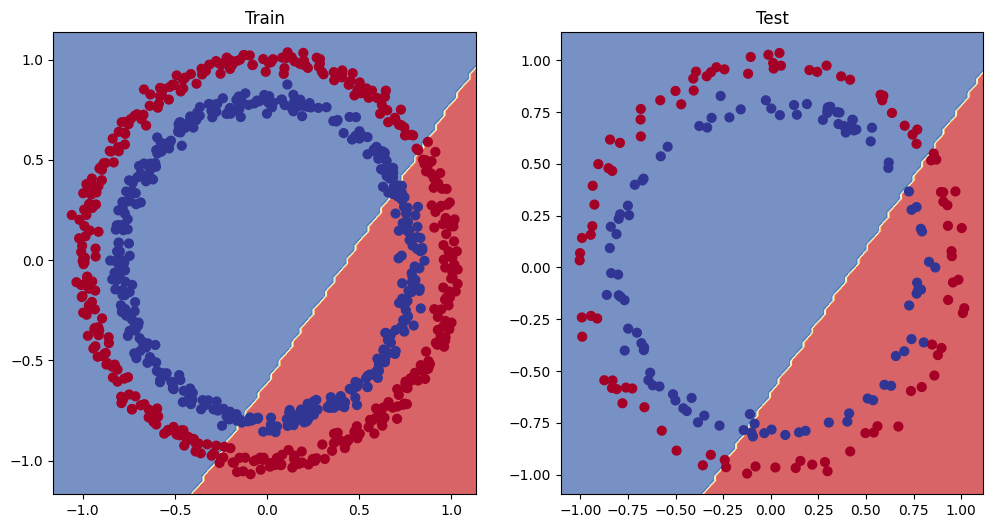

In [69]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, x_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, x_test, y_test)

## improving the model

* add more layers
* add more hidden units
* fit for longer -  add more epochs 
* changing the activation function 
* change the learning rate 
* change the loss function 

In [70]:
weight  = 0.7
bias = 0.3
start = 0
end =1
step = 0.01

x_regression = torch.arange(start,end,step).unsqueeze(dim=1)
y_regression = weight*x_regression +bias
print(len(x_regression))

100


In [71]:
train_split = int(0.8*len(x_regression))
x_train_regression,y_train_regression = x_regression[:train_split],y_regression[:train_split]
x_test_regression, y_test_regression = x_regression[train_split:],y_regression[train_split:]
len(x_train_regression)

80

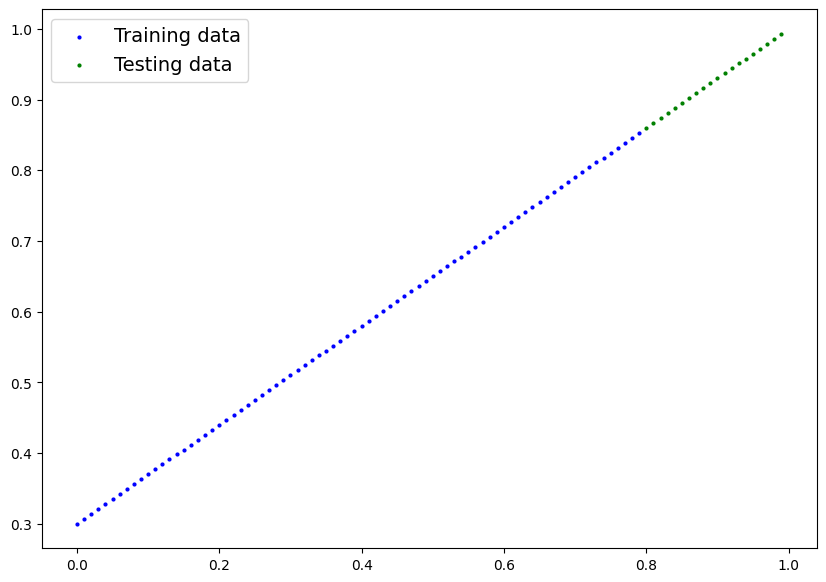

In [72]:
plot_predictions(train_data=x_train_regression,
                 train_labels=y_train_regression,
                 test_data=x_test_regression,
                 test_labels=y_test_regression)

In [73]:
class circleModelv1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=1,out_features=10)
        self.layer_2 = nn.Linear(in_features=10,out_features=10)
        self.layer_3 = nn.Linear(in_features=10,out_features=1)


    def forward(self,x):
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_2 = circleModelv1().to(device)
model_2

circleModelv1(
  (layer_1): Linear(in_features=1, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [74]:
def accuracy_fn(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct/len(y_pred))*100
    return acc


In [77]:
torch.manual_seed(42)
epochs = 1000
x_test1,y_test1 = x_test_regression.to(device),y_test_regression.to(device)
x_train1,y_train1 = x_train_regression.to(device),y_train_regression.to(device)  
loss_fn1 = nn.L1Loss()
optim1 = torch.optim.SGD(params = model_2.parameters(),lr=0.01)
for epoch in range(epochs):
    model_2.train()
    y_logits = model_2(x_train1)
    
    loss = loss_fn1(y_logits,y_train1)
    acc = 1 - (torch.abs(y_logits - y_train1)/y_train1).mean()
    optim1.zero_grad()
    loss.backward()
    optim1.step()
    
    model_2.eval()
    with torch.inference_mode():
        test_logits = model_2(x_test1)
        
        test_loss = loss_fn1(test_logits,y_test1)
        test_acc = 1 - (torch.abs(test_logits - y_test1)/y_test1).mean()
    if epoch%10 ==0:
        print(f'epoch: {epoch}   | Loss: {loss:.5f}.   | accuracy: {acc: .2f}   | test loss: {test_loss: .5f}   | test acc: {test_acc:.2f}')

epoch: 0   | Loss: 0.01782.   | accuracy:  0.97   | test loss:  0.00333   | test acc: 1.00
epoch: 10   | Loss: 0.01706.   | accuracy:  0.97   | test loss:  0.00339   | test acc: 1.00
epoch: 20   | Loss: 0.01754.   | accuracy:  0.97   | test loss:  0.00345   | test acc: 1.00
epoch: 30   | Loss: 0.01778.   | accuracy:  0.97   | test loss:  0.00345   | test acc: 1.00
epoch: 40   | Loss: 0.01764.   | accuracy:  0.97   | test loss:  0.00351   | test acc: 1.00
epoch: 50   | Loss: 0.01788.   | accuracy:  0.97   | test loss:  0.00352   | test acc: 1.00
epoch: 60   | Loss: 0.01775.   | accuracy:  0.97   | test loss:  0.00359   | test acc: 1.00
epoch: 70   | Loss: 0.01761.   | accuracy:  0.97   | test loss:  0.00366   | test acc: 1.00
epoch: 80   | Loss: 0.01724.   | accuracy:  0.97   | test loss:  0.00309   | test acc: 1.00
epoch: 90   | Loss: 0.01749.   | accuracy:  0.97   | test loss:  0.00310   | test acc: 1.00
epoch: 100   | Loss: 0.01674.   | accuracy:  0.97   | test loss:  0.00317   | tes

In [76]:
model_2.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.7474],
                      [ 0.8386],
                      [-0.2685],
                      [ 0.9277],
                      [-0.2253],
                      [ 0.2219],
                      [-0.5157],
                      [ 0.5984],
                      [ 0.8952],
                      [-0.7398]], device='mps:0')),
             ('layer_1.bias',
              tensor([ 0.8181,  0.1893,  0.6798,  0.1390,  0.4719, -0.1165,  0.7276,  0.1469,
                      -0.4521,  0.2444], device='mps:0')),
             ('layer_2.weight',
              tensor([[-6.8272e-02,  4.0207e-03, -9.4606e-02,  2.5110e-01, -2.2979e-01,
                       -1.4690e-01, -6.2611e-02, -1.6088e-01,  3.5127e-02, -3.2492e-01],
                      [ 3.0631e-01, -2.5446e-01,  2.4940e-01,  6.7609e-02, -1.0098e-01,
                        1.9585e-01,  5.0876e-02,  2.6490e-01,  4.2846e-02, -1.0855e-01],
                      [ 8.2267e-03, -1.2545e-01,  

In [79]:
list(model_2.parameters())

[Parameter containing:
 tensor([[ 0.7383],
         [ 0.8390],
         [-0.2793],
         [ 0.9299],
         [-0.2284],
         [ 0.2259],
         [-0.5235],
         [ 0.5986],
         [ 0.8996],
         [-0.7430]], device='mps:0', requires_grad=True),
 Parameter containing:
 tensor([ 0.7891,  0.1792,  0.6672,  0.1315,  0.4688, -0.1201,  0.7240,  0.1302,
         -0.4544,  0.2409], device='mps:0', requires_grad=True),
 Parameter containing:
 tensor([[-0.0548,  0.0132, -0.0909,  0.2607, -0.2282, -0.1468, -0.0610, -0.1552,
           0.0399, -0.3306],
         [ 0.2960, -0.2569,  0.2413,  0.0658, -0.1072,  0.1965,  0.0419,  0.2623,
           0.0489, -0.1124],
         [-0.0067, -0.1343,  0.0928,  0.2336,  0.1588, -0.1368,  0.1504,  0.0223,
           0.1550, -0.1781],
         [-0.2243, -0.0768, -0.2014,  0.3046,  0.1164,  0.1292,  0.1343,  0.0269,
           0.2490, -0.2358],
         [ 0.0055, -0.2281,  0.0966, -0.1222,  0.0984, -0.0665,  0.2653, -0.1949,
          -0.1995, -0

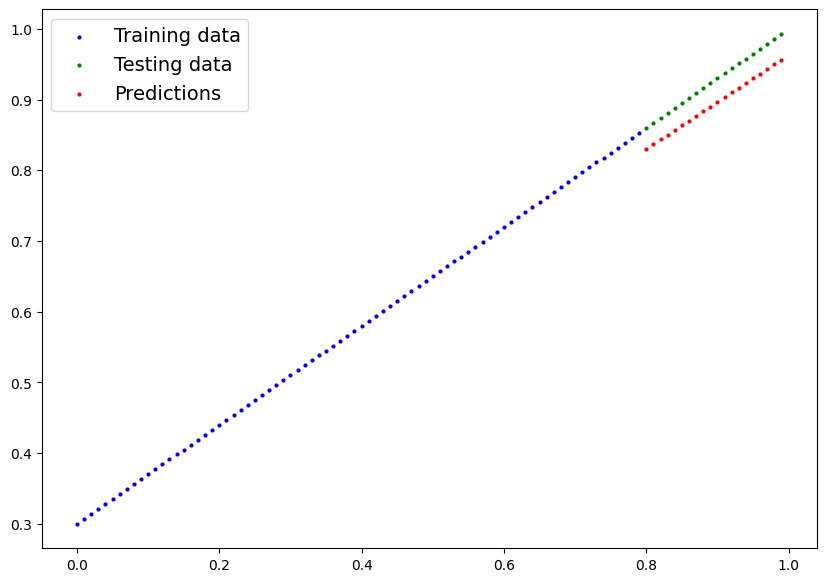

In [80]:
model_2.eval()
with torch.inference_mode():
    y_pred = model_2(x_test1)

plot_predictions(train_data=x_train1.cpu(),
                 train_labels=y_train1.cpu(),
                 test_data=x_test1.cpu(),
                 test_labels=y_test1.cpu(),
                 predictions=y_pred.cpu())

## how to see the number of parameter in model


In [84]:
unique_params = sum(dict((p.data_ptr(), p.numel()) for p in model_2.parameters()).values())
unique_params

141

# making model for non linear data 

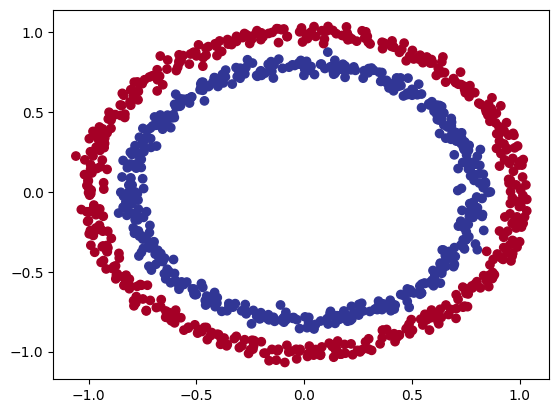

In [85]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000
x,y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

plt.scatter(x[:,0],x[:,1],c=y,cmap=plt.cm.RdYlBu)

In [86]:
import torch
from sklearn.model_selection import train_test_split

x = torch.from_numpy(x).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)
x_train[:5],y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))